Checking language type distribution in existing pretraining corpora

In [1]:
import os
import pandas as pd
import tiktoken
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from huggingface_hub import HfApi, hf_hub_download

tqdm.pandas()

FONT_SIZES = {"small": 14, "medium": 18, "large": 24}

PLOT_PARAMS = {
    "font.family": "serif",
    "font.serif": ["Times"],
    "font.size": FONT_SIZES.get("medium"),
    "axes.titlesize": FONT_SIZES.get("large"),
    "axes.labelsize": FONT_SIZES.get("large"),
    "xtick.labelsize": FONT_SIZES.get("large"),
    "ytick.labelsize": FONT_SIZES.get("large"),
    "legend.fontsize": FONT_SIZES.get("medium"),
    "figure.titlesize": FONT_SIZES.get("medium"),
    "text.usetex": True,
}

plt.rcParams.update(PLOT_PARAMS)

/Users/ljvmiranda/Developer/scratch/2026-03-20-madlad/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_madlad(lang: str, split: str = "clean_docs") -> pd.DataFrame:
    """Load MADLAD-400 data for a given language code into a DataFrame.

    Args:
        lang: Language code (e.g. 'ceb', 'tgl', 'en').
        split: Which split to load — 'clean_docs', 'noisy_docs', or 'all'.
    """
    api = HfApi()
    files = api.list_repo_tree(
        "allenai/MADLAD-400",
        path_in_repo=f"data-v1p5/{lang}",
        repo_type="dataset",
    )

    local_dir = f"data/{lang}"
    os.makedirs(local_dir, exist_ok=True)

    paths = []
    for f in files:
        if not f.rfilename.endswith(".jsonl.gz"):
            continue
        if split != "all" and split not in f.rfilename:
            continue
        path = hf_hub_download(
            "allenai/MADLAD-400",
            filename=f.rfilename,
            repo_type="dataset",
            local_dir=local_dir,
        )
        paths.append(path)

    print(f"Downloaded {len(paths)} files for '{lang}'")
    return pd.concat([pd.read_json(p, lines=True) for p in paths], ignore_index=True)

In [3]:
df = load_madlad("ceb", split="clean_docs")
df.head(5)

Downloaded 10 files for 'ceb'


,text,timestamp,url
0,Ang Brand Africa nga nagpadayon sa pagsugat sa...,2021-09-24 00:24:28+00:00,https://ceb.eturbonews.com/165852/brand-africa...
1,"Gipalihok pinaagi sa Hiyas sa pagtugnaw, pagla...",2022-05-22 18:13:01+00:00,https://cleverplus.news/news/1409-ya_no_vayas_...
2,Ang Apple adunay labing kapuslan nga mga tinda...,2021-09-26 04:32:23+00:00,https://www.soydemac.com/ceb/apple-ang-labing-...
3,Hotels.com helps you to find the best hotel fo...,2021-11-27 03:08:03+00:00,https://sg.hotels.com/de700471/ugento-italy-ho...
4,Purohan batok COVID-19 | Banat\nPurohan batok ...,2020-11-28 12:00:41+00:00,https://www.philstar.com/banat/opinyon/2020/06...


Before we do some fun stuff, might be nice to just learn more about the data

In [4]:
enc = tiktoken.get_encoding("cl100k_base")
df["token_length"] = df["text"].progress_apply(lambda x: len(enc.encode(x)))

100%|██████████| 66164/66164 [00:22<00:00, 2881.34it/s]


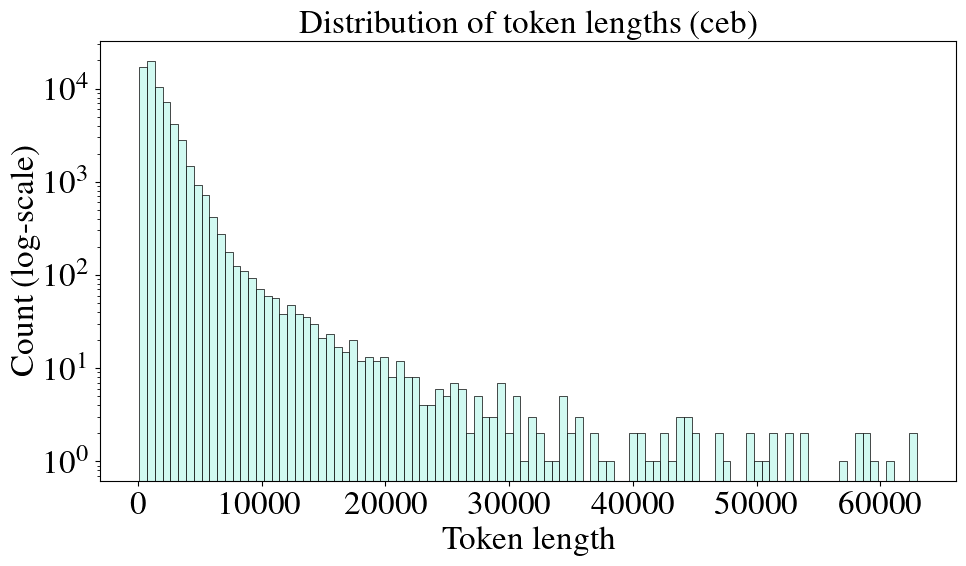

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df["token_length"], bins=100, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.set_yscale("log")
ax.set_xlabel("Token length")
ax.set_ylabel("Count (log-scale)")
ax.set_title("Distribution of token lengths (ceb)")
fig.tight_layout()
plt.show()

Ideally, I'd check each text and confirm which data type they have. But assuming I don't have any knowledge about the language, what can I do? Maybe...

- Check the URLs? Perhaps there's a way to cross-reference URLs to a certain domain.
- Use an LLM? Maybe something like [this work](https://arxiv.org/pdf/2502.10341). But how do you validate this?

Let's start by checking the URLs

In [6]:
from urllib.parse import urlparse

df["tld"] = df["url"].apply(lambda x: "." + urlparse(x).netloc.rsplit(".", 1)[-1])

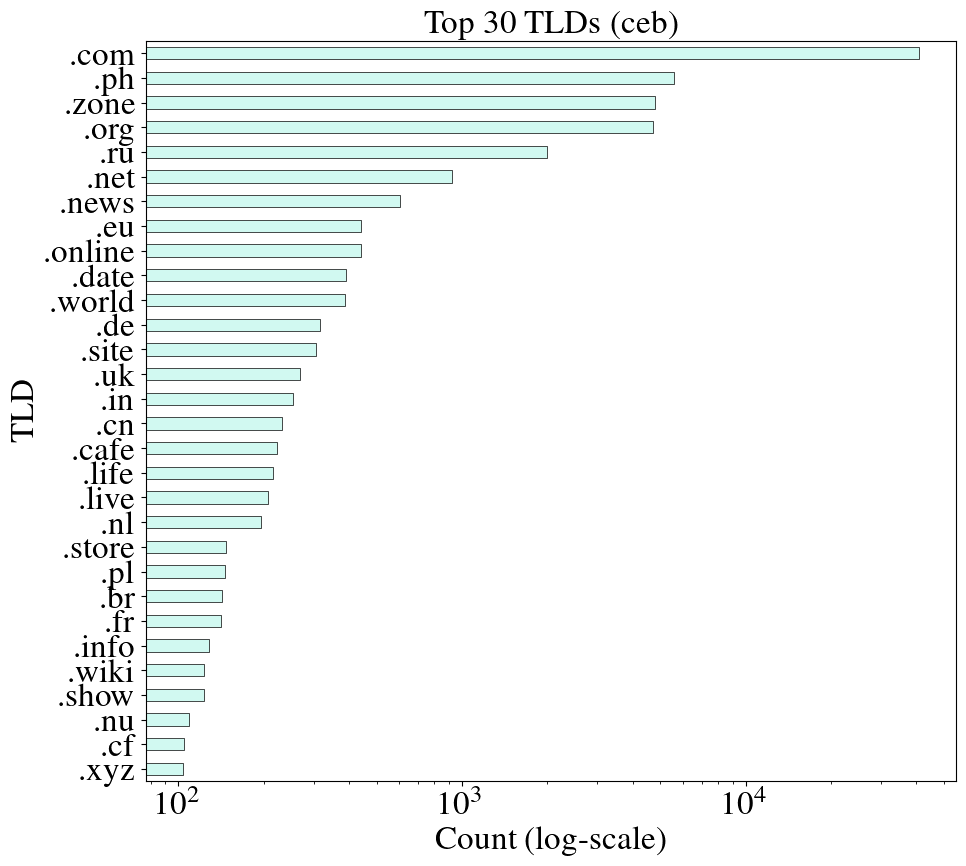

In [7]:
top_n = 30
tld_counts = df["tld"].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(10, 9))
tld_counts.plot.barh(ax=ax, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("Count (log-scale)")
ax.set_ylabel("TLD")
ax.set_title(f"Top {top_n} TLDs (ceb)")
fig.tight_layout()
plt.show()

### Topic classification

Using [WebOrganizer/TopicClassifier](https://huggingface.co/WebOrganizer/TopicClassifier) to classify documents into 24 topic categories.

In [13]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

TOPIC_LABELS = {
    0: "Adult",
    1: "Art & Design",
    2: "Software Dev.",
    3: "Crime & Law",
    4: "Education & Jobs",
    5: "Hardware",
    6: "Entertainment",
    7: "Social Life",
    8: "Fashion & Beauty",
    9: "Finance & Business",
    10: "Food & Dining",
    11: "Games",
    12: "Health",
    13: "History",
    14: "Home & Hobbies",
    15: "Industrial",
    16: "Literature",
    17: "Politics",
    18: "Religion",
    19: "Science & Tech.",
    20: "Software",
    21: "Sports & Fitness",
    22: "Transportation",
    23: "Travel",
}

device = torch.device("cpu")

topic_tokenizer = AutoTokenizer.from_pretrained("WebOrganizer/TopicClassifier")
topic_model = (
    AutoModelForSequenceClassification.from_pretrained(
        "WebOrganizer/TopicClassifier",
        trust_remote_code=True,
        use_memory_efficient_attention=False,
        torch_dtype=torch.float32,
    )
    .to(device)
    .eval()
)

Loading weights: 100%|██████████| 139/139 [00:00<00:00, 16686.94it/s]


In [16]:
@torch.no_grad()
def classify_topic(text: str, url: str = "") -> str:
    """Classify a single document into one of 24 topic categories."""
    input_text = f"{url}\n\n{text}" if url else text
    inputs = topic_tokenizer([input_text], return_tensors="pt", truncation=True).to(
        device
    )
    seq_len = inputs["input_ids"].shape[1]
    inputs["position_ids"] = torch.arange(
        seq_len, dtype=torch.long, device=device
    ).unsqueeze(0)
    outputs = topic_model(**inputs)
    pred = outputs.logits.softmax(dim=-1).argmax(dim=-1).item()
    return TOPIC_LABELS[pred]


# Quick test
print("{url}\nn{text}".format(url=df["url"].iloc[0], text=df["text"].iloc[0]))
classify_topic(df["text"].iloc[0], df["url"].iloc[0])

https://ceb.eturbonews.com/165852/brand-africa-nga-nagpadayon-sa-unahan-sa-zambia-nagtagbo-sa-mga-asosasyon-sa-pagdumala-sa-pantalan/
nAng Brand Africa nga nagpadayon sa pagsugat sa Zambia sa Ports Management Association\nHome » Pinakabag-ong Mga Artikulo sa Balita » Mga Kasayuran nga Balita » Ang Brand Africa nga nagpadayon sa pagsugat sa Zambia sa Ports Management Association\nMga Kasayuran nga Balita • Pagbungkag sa Balita sa Pagbiyahe • Pag-cruis • Balita • Turismo • Transportation • Pagbag-o sa Destinasyon sa Pagbiyahe • Balita sa Travel Wire • Balita sa Pagbungkag sa Zambia\nAng Ministro sa Turismo ug Sining nga si Hon. Gisulti ni Charles Banda nga ang Zambia sa dili madugay makita kung unsa ang labing kaayo aron mapalambo ang turismo sa cruise pinaagi sa paggamit sa mga magamit nga mga tubig nga tubig ingon ang Seychelles 'Head of Mission sa Zambia, si Jamil (Jimmy) Butt, nagsulti nga ang iyang nasud gusto nga magtubo ang usa ka bilateral nga panaghigalaay sa linya sa Kasabutan 

'Adult'

In [20]:
df_sample = df.sample(100)
df_sample["topic"] = df_sample.progress_apply(
    lambda row: classify_topic(row["text"], row["url"]), axis=1
)

100%|██████████| 100/100 [00:41<00:00,  2.43it/s]


In [44]:
import textwrap


def inspect_topic(df: pd.DataFrame, topic: str, n: int = 5) -> pd.DataFrame:
    """Sample n rows from a given topic and display text snippets."""
    subset = df[df["topic"] == topic]
    sample = subset.sample(min(n, len(subset)))
    for _, row in sample.iterrows():
        print(f"[{row['topic']}] {row['url']}")
        print(textwrap.fill(row["text"][:300], width=70))
        print("---")
    return sample


inspect_topic(df_sample, "Finance & Business", n=5)

[Finance & Business] https://ceb.eturbonews.com/3003735/lufthansa-kantidad-mao-ang-hapit-sa-pagdugang-sa-us2-5-bilyon/
Ang Lufthansa Value hapit magdugang sa US $ 2.5 bilyon\nHome »
Pinakabag-ong Mga Artikulo sa Balita » Airlines » Ang Lufthansa Value
hapit magdugang sa US $ 2.5 bilyon\nAirlines • aviation • Pagbungkag
sa Balita sa Europa • Pagbungkag sa Balita sa Pagbiyahe • Pagbiyahe sa
Negosyo • Balita sa Pagbung
---
[Finance & Business] https://www.actualidadecommerce.com/ceb/Ang-tool-sa-pagpadala-sa-sendcloud-nagpataas-sa-5-milyon-nga-euro/
Ang gamit sa pagpadala nga "SendCloud" nagpataas sa 5 milyon nga Euros
| Balita sa ECommerce\nSendCloud ang gamit sa pagpadala nagpataas sa €
5 milyon salamat sa mga namuhunan niini henQ, BOM ug Tiin Capital. Sa
kini nga kantidad nga salapi, ang Dutch nga adunay ilang mga timbangan
gusto nga mag-ayo
---
[Finance & Business] https://www.actualidadecommerce.com/ceb/matang-sa-mga-ganghaan-sa-pagbayad/
Mga tipo sa mga ganghaan sa pagbayad | balita 

,text,timestamp,url,token_length,tld,topic,format
23139,Ang Lufthansa Value hapit magdugang sa US $ 2....,2021-10-17 03:01:58+00:00,https://ceb.eturbonews.com/3003735/lufthansa-k...,1185,.com,Finance & Business,Academic Writing
54178,"Ang gamit sa pagpadala nga ""SendCloud"" nagpata...",2021-10-22 16:21:24+00:00,https://www.actualidadecommerce.com/ceb/Ang-to...,706,.com,Finance & Business,Academic Writing
59672,Mga tipo sa mga ganghaan sa pagbayad | balita ...,2022-06-26 01:08:13+00:00,https://www.actualidadecommerce.com/ceb/matang...,2432,.com,Finance & Business,Academic Writing
27122,Digimind: Ang Social Media Analytics alang sa ...,2021-07-23 23:26:20+00:00,https://ceb.martech.zone/digimind-social-media...,1143,.zone,Finance & Business,Academic Writing
27457,Pag-target sa Konteksto: Kaluwasan sa Paghimo ...,2021-09-24 00:11:11+00:00,https://ceb.martech.zone/contextual-targeting-...,1802,.zone,Finance & Business,Academic Writing


<>:9: SyntaxWarning: invalid escape sequence '\#'
<>:9: SyntaxWarning: invalid escape sequence '\#'
/var/folders/sr/yrkfz9x97657016n6k2bm8280000gn/T/ipykernel_21854/1629300319.py:9: SyntaxWarning: invalid escape sequence '\#'
  ax.set_title(f"Topic distribution (ceb), \# of samples = {len(df_sample)}")


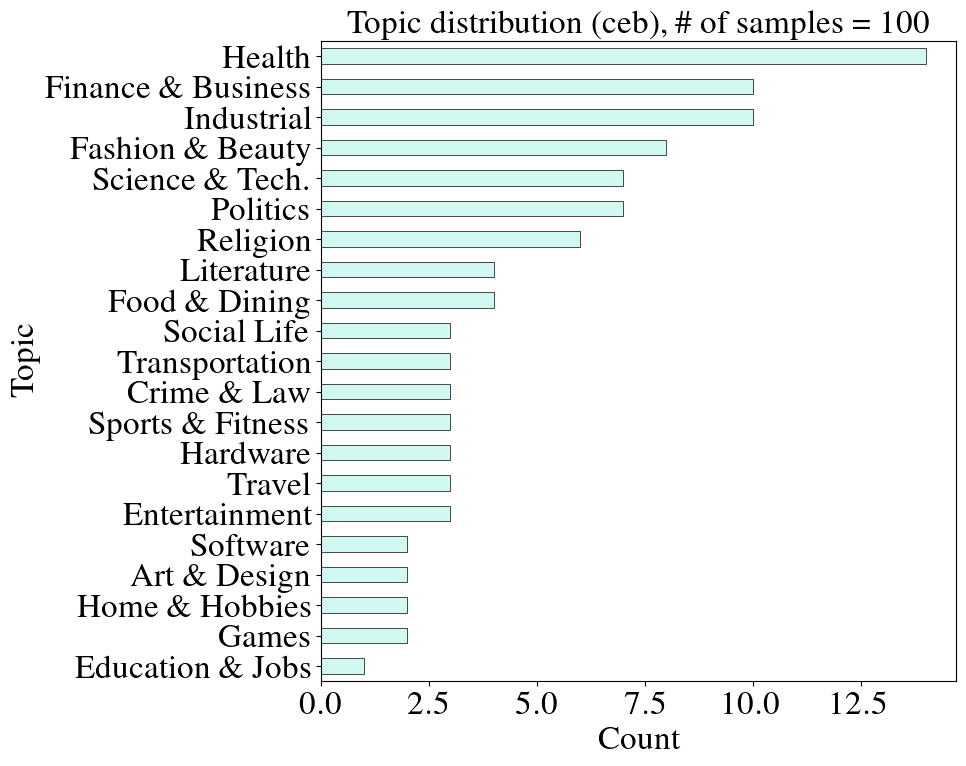

In [33]:
topic_counts = df_sample["topic"].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
topic_counts.plot.barh(ax=ax, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_yticklabels([label.replace("&", r"\&") for label in topic_counts.index])
ax.set_xlabel("Count")
ax.set_ylabel("Topic")
ax.set_title(f"Topic distribution (ceb), \# of samples = {len(df_sample)}")
fig.tight_layout()
plt.show()

### Format classification

Using [WebOrganizer/FormatClassifier](https://huggingface.co/WebOrganizer/FormatClassifier) to classify documents into 24 format categories.

In [36]:
FORMAT_LABELS = {
    0: "Academic Writing",
    1: "Content Listing",
    2: "Creative Writing",
    3: "Customer Support",
    4: "Comment Section",
    5: "FAQ",
    6: "Truncated",
    7: "Knowledge Article",
    8: "Legal Notices",
    9: "Listicle",
    10: "News Article",
    11: "Nonfiction Writing",
    12: "About (Org.)",
    13: "News (Org.)",
    14: "About (Pers.)",
    15: "Personal Blog",
    16: "Product Page",
    17: "Q&A Forum",
    18: "Spam / Ads",
    19: "Structured Data",
    20: "Documentation",
    21: "Audio Transcript",
    22: "Tutorial",
    23: "User Review",
}

format_tokenizer = AutoTokenizer.from_pretrained("WebOrganizer/FormatClassifier")
format_model = (
    AutoModelForSequenceClassification.from_pretrained(
        "WebOrganizer/FormatClassifier",
        trust_remote_code=True,
        use_memory_efficient_attention=False,
        torch_dtype=torch.float32,
    )
    .to(device)
    .eval()
)

A new version of the following files was downloaded from https://huggingface.co/WebOrganizer/FormatClassifier:
- configuration.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/WebOrganizer/FormatClassifier:
- modeling.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Loading weights: 100%|██████████| 139/139 [00:00<00:00, 13975.32it/s]


In [37]:
@torch.no_grad()
def classify_format(text: str, url: str = "") -> str:
    """Classify a single document into one of 24 format categories."""
    input_text = f"{url}\n\n{text}" if url else text
    inputs = format_tokenizer([input_text], return_tensors="pt", truncation=True).to(
        device
    )
    seq_len = inputs["input_ids"].shape[1]
    inputs["position_ids"] = torch.arange(
        seq_len, dtype=torch.long, device=device
    ).unsqueeze(0)
    outputs = format_model(**inputs)
    pred = outputs.logits.softmax(dim=-1).argmax(dim=-1).item()
    return FORMAT_LABELS[pred]


# Quick test
classify_format(df["text"].iloc[0], df["url"].iloc[0])

'Academic Writing'

In [38]:
df_sample["format"] = df_sample.progress_apply(
    lambda row: classify_format(row["text"], row["url"]), axis=1
)

100%|██████████| 100/100 [00:43<00:00,  2.29it/s]


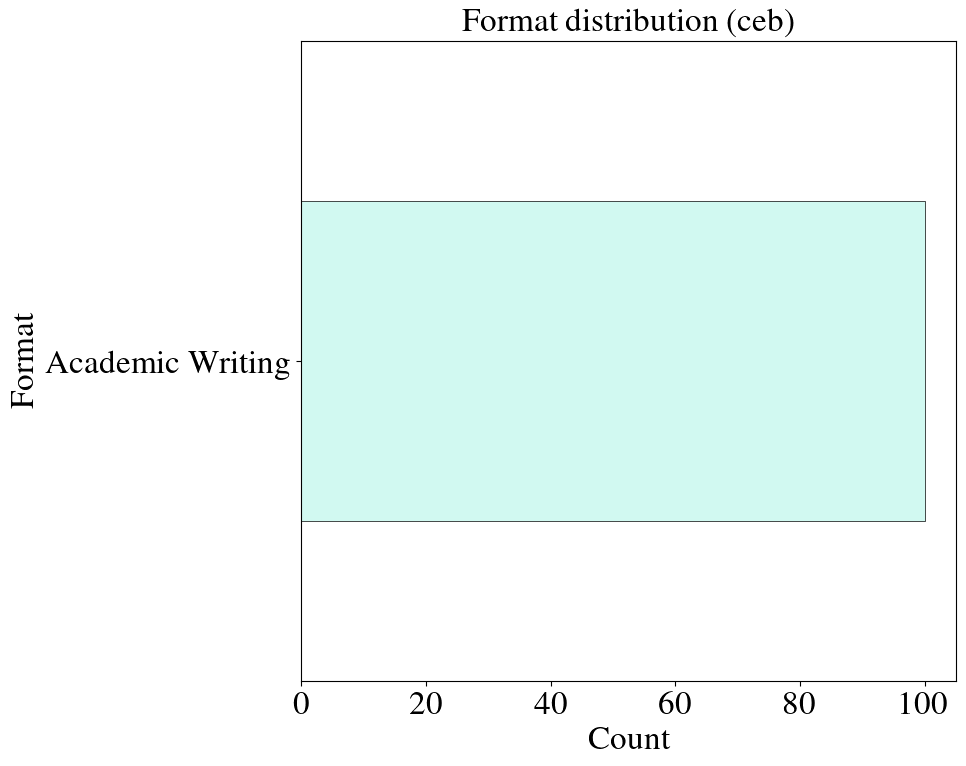

In [39]:
format_counts = df_sample["format"].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
format_counts.plot.barh(ax=ax, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_yticklabels([label.replace("&", r"\&") for label in format_counts.index])
ax.set_xlabel("Count")
ax.set_ylabel("Format")
ax.set_title("Format distribution (ceb)")
fig.tight_layout()
plt.show()

In [ ]:
@torch.no_grad()
def classify_topic(text: str, url: str = "") -> str:
    input_text = f"{url}\n\n{text}" if url else text
    inputs = topic_tokenizer([input_text], return_tensors="pt", truncation=True).to(
        device
    )
    outputs = topic_model(**inputs)
    pred = outputs.logits.softmax(dim=-1).argmax(dim=-1).item()
    return TOPIC_LABELS[pred]


# Quick test
classify_topic(df["text"].iloc[0], df["url"].iloc[0])

IndexError: index 8567972256 is out of bounds for dimension 0 with size 1012

In [ ]:
def inspect_format(df: pd.DataFrame, fmt: str, n: int = 5) -> pd.DataFrame:
    """Sample n rows from a given format and display text snippets."""
    subset = df[df["format"] == fmt]
    sample = subset.sample(min(n, len(subset)))
    for _, row in sample.iterrows():
        print(f"[{row['format']}] {row['url']}")
        print(textwrap.fill(row["text"][:300], width=70))
        print("---")
    return sample


inspect_format(df_sample, "News Article", n=3)

### Embeddings and keyword extraction

Using [intfloat/multilingual-e5-large](https://huggingface.co/intfloat/multilingual-e5-large) for multilingual embeddings and [KeyBERT](https://github.com/MaartenGr/KeyBERT) for keyword extraction. UMAP for dimensionality reduction.

In [45]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("intfloat/multilingual-e5-large")

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 24067.34it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [49]:
import numpy as np

df_sample_umap = df.sample(1_000)
# multilingual-e5 expects "query: " or "passage: " prefix
texts = ["passage: " + t for t in df_sample_umap["text"].tolist()]
embeddings = embed_model.encode(texts, show_progress_bar=True, batch_size=16)
embeddings = np.array(embeddings)

Batches: 100%|██████████| 63/63 [01:14<00:00,  1.19s/it]


In [47]:
from umap import UMAP

reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
coords = reducer.fit_transform(embeddings)
df_sample["umap_x"] = coords[:, 0]
df_sample["umap_y"] = coords[:, 1]

/Users/ljvmiranda/Developer/scratch/2026-03-20-madlad/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


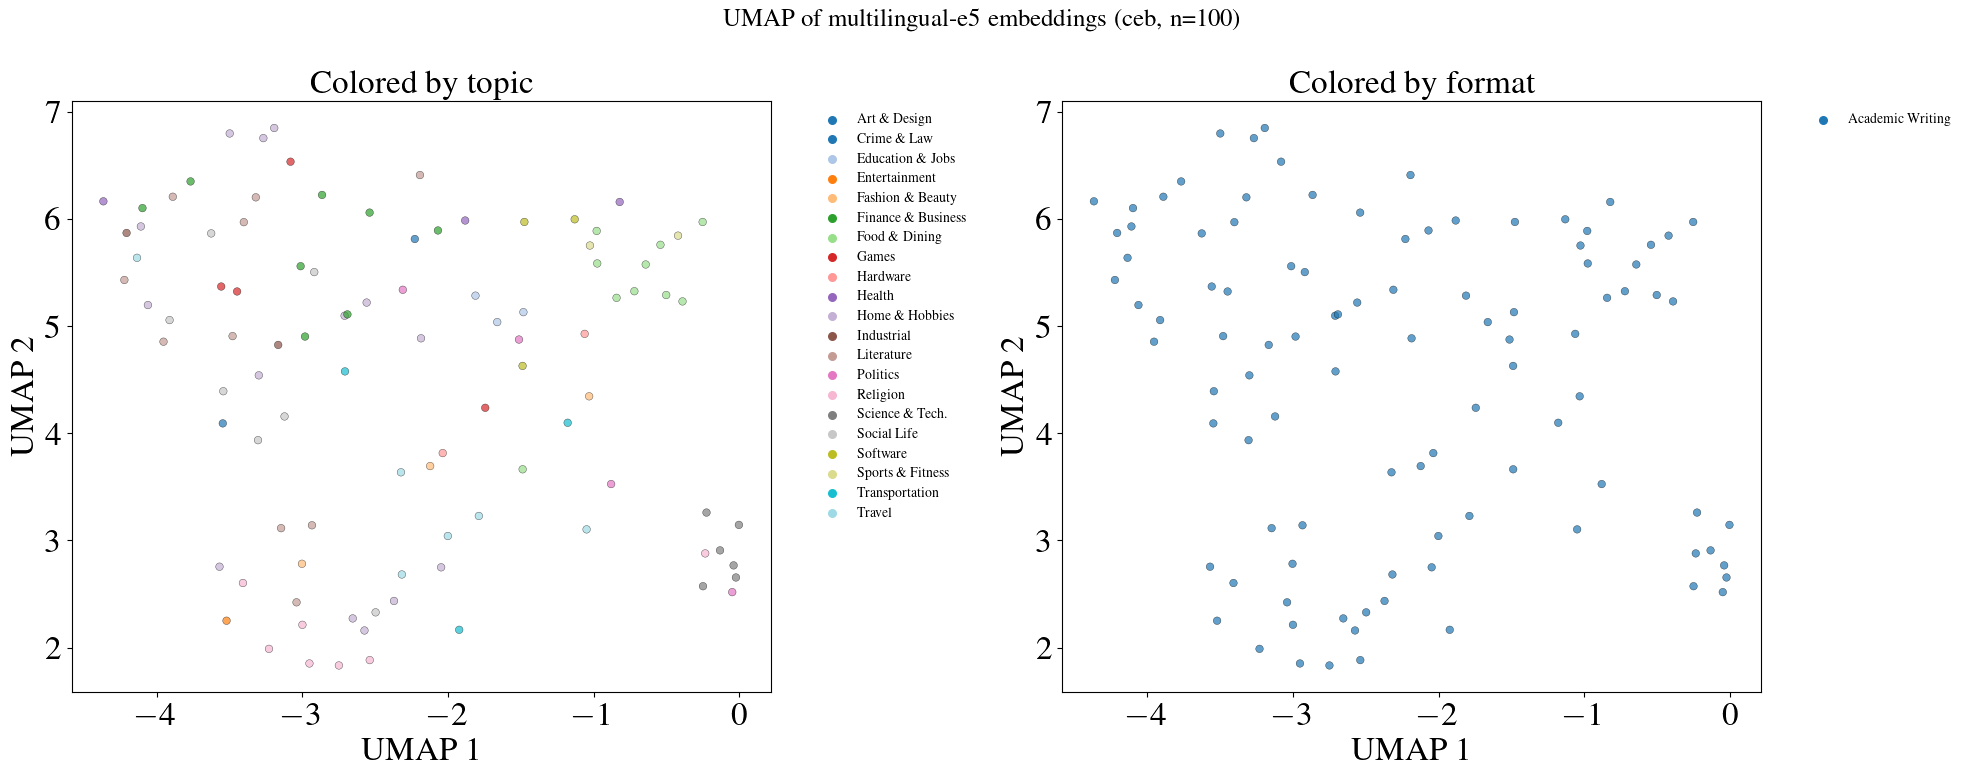

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Color by topic
topics = df_sample["topic"].astype("category")
topic_codes = topics.cat.codes
sc0 = axes[0].scatter(
    df_sample["umap_x"],
    df_sample["umap_y"],
    c=topic_codes,
    cmap="tab20",
    s=30,
    alpha=0.7,
    edgecolors="black",
    linewidth=0.3,
)
axes[0].set_title("Colored by topic")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

# Color by format
formats = df_sample["format"].astype("category")
format_codes = formats.cat.codes
sc1 = axes[1].scatter(
    df_sample["umap_x"],
    df_sample["umap_y"],
    c=format_codes,
    cmap="tab20",
    s=30,
    alpha=0.7,
    edgecolors="black",
    linewidth=0.3,
)
axes[1].set_title("Colored by format")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

# Legends
for ax, cats in [(axes[0], topics), (axes[1], formats)]:
    handles = []
    cmap = plt.cm.tab20
    for i, label in enumerate(cats.cat.categories):
        label_esc = label.replace("&", r"\&")
        handles.append(
            ax.scatter(
                [], [], c=[cmap(i / len(cats.cat.categories))], s=30, label=label_esc
            )
        )
    ax.legend(
        handles=handles,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=10,
        frameon=False,
    )

fig.suptitle("UMAP of multilingual-e5 embeddings (ceb, n={})".format(len(df_sample)))
fig.tight_layout()
plt.show()

In [ ]:
from keybert import KeyBERT

kw_model = KeyBERT(model=embed_model)

df_sample["keywords"] = df_sample["text"].progress_apply(
    lambda t: [kw for kw, _ in kw_model.extract_keywords(t, top_n=5)]
)

In [ ]:
def inspect_embeddings(
    df: pd.DataFrame, topic: str = None, fmt: str = None, n: int = 5
) -> pd.DataFrame:
    """Sample rows and show keywords, topic, format, and text snippet."""
    subset = df.copy()
    if topic:
        subset = subset[subset["topic"] == topic]
    if fmt:
        subset = subset[subset["format"] == fmt]
    sample = subset.sample(min(n, len(subset)))
    for _, row in sample.iterrows():
        print(f"[{row['topic']} | {row['format']}] {row['url']}")
        print(f"Keywords: {', '.join(row['keywords'])}")
        print(textwrap.fill(row["text"][:200], width=70))
        print("---")
    return sample


inspect_embeddings(df_sample, topic="Health", n=3)